In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

path = "SeoulBikeData.csv"

## 1) Load data

In [2]:
df = pd.read_csv(path, parse_dates=["Date"])
print("Rows, Cols:", df.shape)
df.head()

Rows, Cols: (8760, 14)


,Date,Rented Bike Count,Hour,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


## 2) Basic cleaning (functional days, chronology, drop `Date`)

In [3]:
# Keep only functional hours
df = df[df["Functioning Day"].astype(str).str.lower() != "no"].copy()

# drop Date and Functioning Day column
df = df.drop(columns=["Date","Functioning Day"])

# Encode Holiday to 0/1
df["Holiday"] = df["Holiday"].map({"No Holiday": 0, "Holiday": 1}).fillna(0).astype(int)

rename = {
    "Temperature(°C)":"Temperature",
    "Humidity(%)":"Humidity",
    "Wind speed (m/s)":"Wind_speed",
    "Visibility (10m)":"Visibility",
    "Solar Radiation (MJ/m2)":"Solar_Radiation",
    "Rainfall(mm)":"Rainfall",
    "Snowfall (cm)":"Snowfall",
    "Dew point temperature":"Dew_point_temperature",
    "Solar radiation":"Solar_Radiation",
    "Rented Bike Count":"Rented_Bike_Count",
    "Holiday":"Holiday_num"
    
}
df.rename(columns={k:v for k,v in rename.items() if k in df.columns}, inplace=True)

# OneHotEncoder for Seasons
season_enc = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
season_array = season_enc.fit_transform(df[["Seasons"]])
season_cols = season_enc.get_feature_names_out(["Seasons"])
season_df = pd.DataFrame(season_array, columns=season_cols, index=df.index)

df = pd.concat([df.drop(columns=["Seasons"]), season_df], axis=1)

df.head(3)
print(df["Rented_Bike_Count"].mean())

729.1569994093326


## 3) Feature engineering

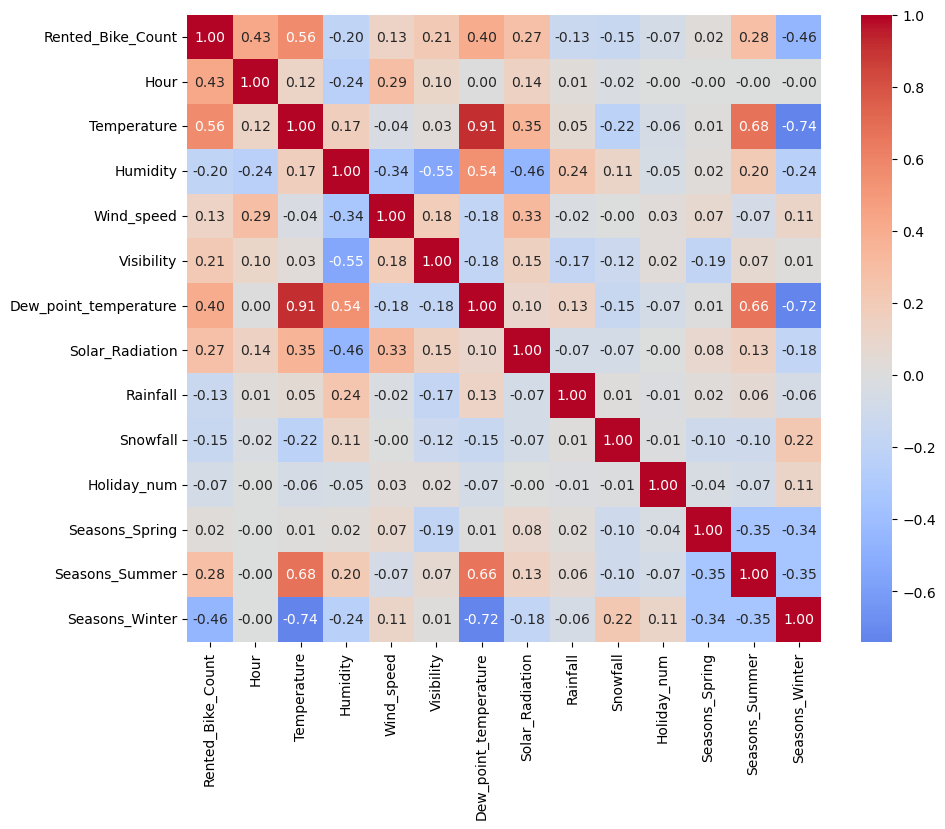

In [4]:
num_cols = [
    "Rented_Bike_Count", "Hour",
    "Temperature", "Humidity", "Wind_speed", "Visibility",
    "Dew_point_temperature", "Solar_Radiation",
    "Rainfall", "Snowfall",
    "Holiday_num",
    "Seasons_Spring",
    "Seasons_Summer",
    "Seasons_Winter"
] 

corr = df[num_cols].corr()
plt.figure(figsize=(max(10, 0.6*len(num_cols)), max(8, 0.6*len(num_cols))))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.tight_layout()
plt.show()

In [5]:
#  PCA on correlated weather features
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
sub = df[["Temperature","Dew_point_temperature"]].dropna()

scaler = StandardScaler()
sub_scaled = scaler.fit_transform(sub)

# Apply PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(sub_scaled) 
print("Explained variance ratio:", pca.explained_variance_ratio_)



Explained variance ratio: [0.95723348 0.04276652]


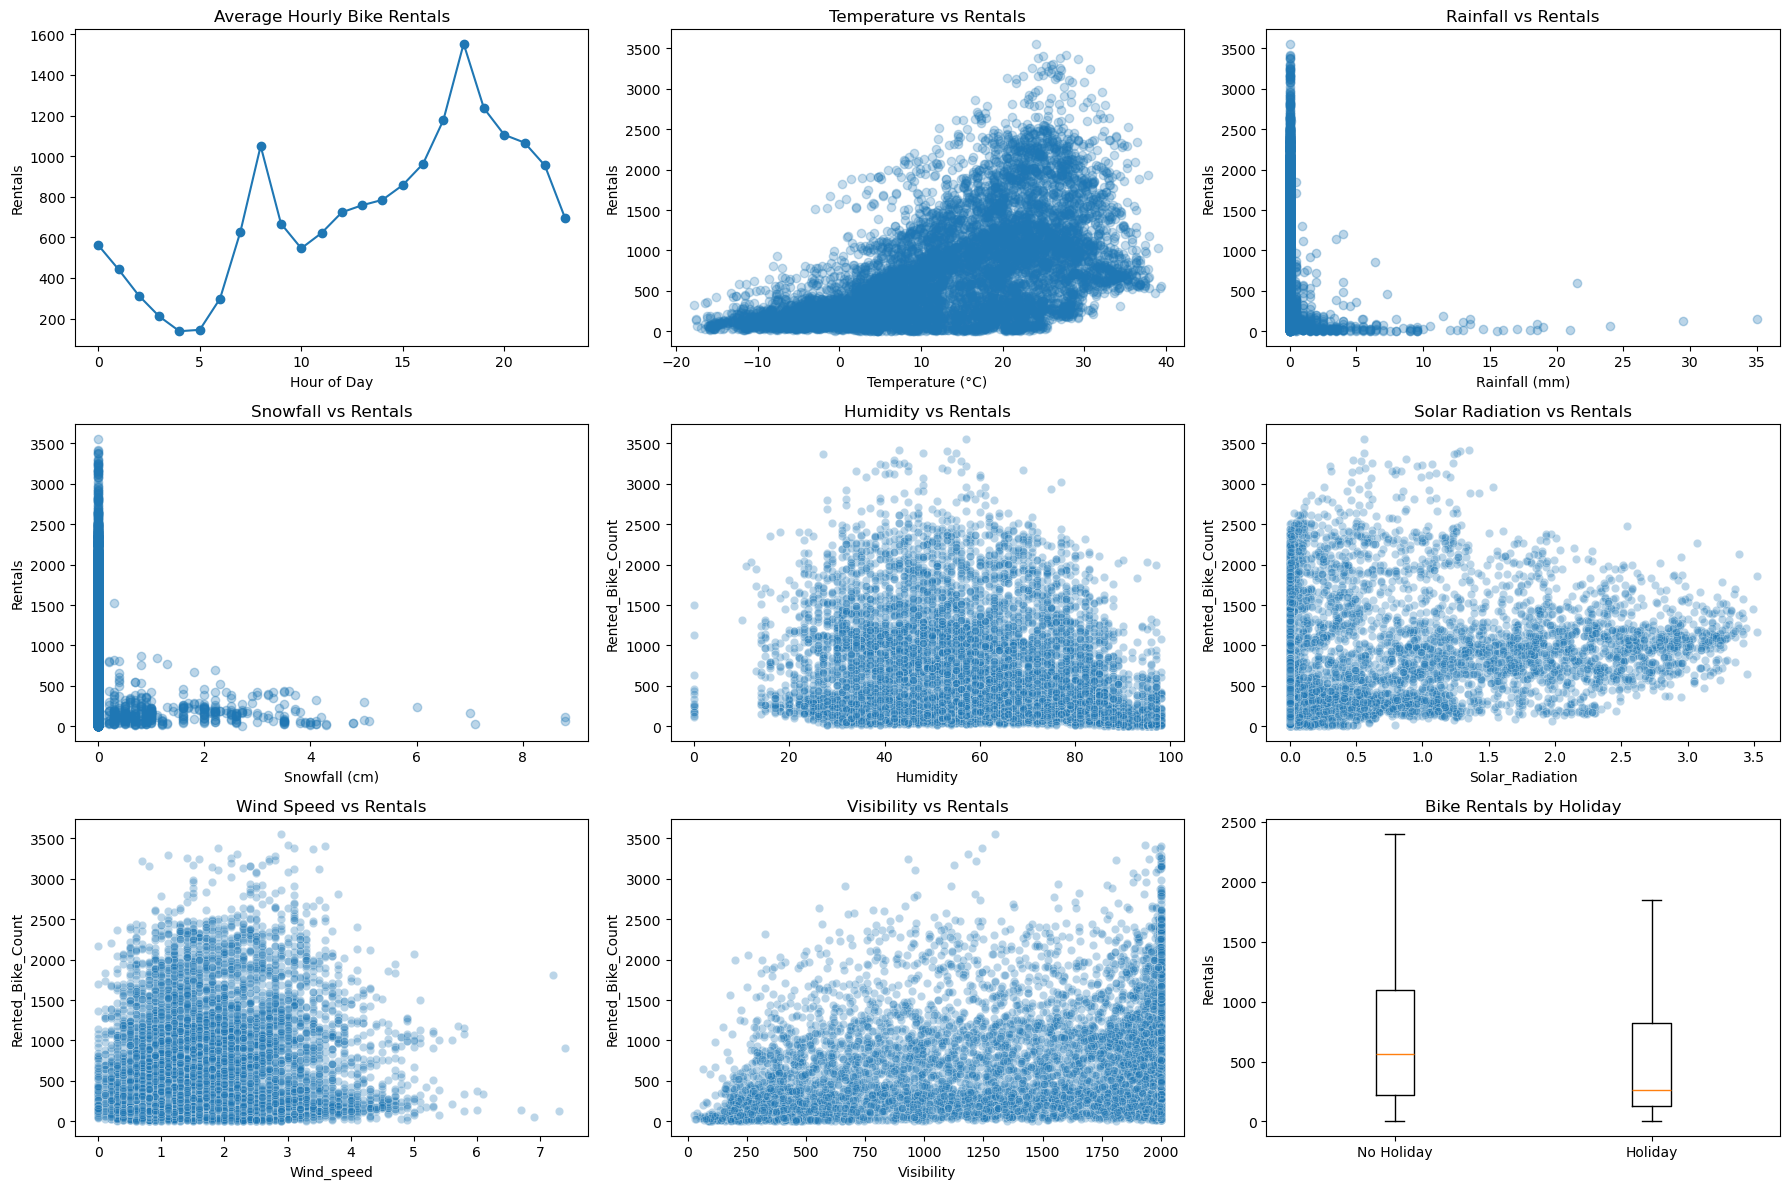

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(18,12))

hourly_avg = df.groupby("Hour")["Rented_Bike_Count"].mean()
axes[0,0].plot(hourly_avg.index, hourly_avg.values, marker="o")
axes[0,0].set_title("Average Hourly Bike Rentals")
axes[0,0].set_xlabel("Hour of Day")
axes[0,0].set_ylabel("Rentals")

axes[0,1].scatter(df["Temperature"], df["Rented_Bike_Count"], alpha=0.25)
axes[0,1].set_title("Temperature vs Rentals")
axes[0,1].set_xlabel("Temperature (°C)")
axes[0,1].set_ylabel("Rentals")

axes[0,2].scatter(df["Rainfall"], df["Rented_Bike_Count"], alpha=0.3)
axes[0,2].set_title("Rainfall vs Rentals")
axes[0,2].set_xlabel("Rainfall (mm)")
axes[0,2].set_ylabel("Rentals")

axes[1,0].scatter(df["Snowfall"], df["Rented_Bike_Count"], alpha=0.3)
axes[1,0].set_title("Snowfall vs Rentals")
axes[1,0].set_xlabel("Snowfall (cm)")
axes[1,0].set_ylabel("Rentals")

sns.scatterplot(ax=axes[1,1], x="Humidity", y="Rented_Bike_Count", data=df, alpha=0.3)
axes[1,1].set_title("Humidity vs Rentals")

sns.scatterplot(ax=axes[1,2], x="Solar_Radiation", y="Rented_Bike_Count", data=df, alpha=0.3)
axes[1,2].set_title("Solar Radiation vs Rentals")

sns.scatterplot(ax=axes[2,0], x="Wind_speed", y="Rented_Bike_Count", data=df, alpha=0.3)
axes[2,0].set_title("Wind Speed vs Rentals")

sns.scatterplot(ax=axes[2,1], x="Visibility", y="Rented_Bike_Count", data=df, alpha=0.3)
axes[2,1].set_title("Visibility vs Rentals")

axes[2,2].boxplot(
    [df[df["Holiday_num"]==0]["Rented_Bike_Count"], df[df["Holiday_num"]==1]["Rented_Bike_Count"]],
    labels=["No Holiday", "Holiday"],
    showfliers=False
)
axes[2,2].set_title("Bike Rentals by Holiday")
axes[2,2].set_ylabel("Rentals")

plt.tight_layout()
plt.savefig("EDA_plots.png", dpi=300)
plt.show()

In [7]:
base_num = ["Hour","Temperature","Humidity","Wind_speed","Visibility","Solar_Radiation",
            "Rainfall","Snowfall", "Seasons_Spring", "Seasons_Summer", "Seasons_Winter",
            "Holiday_num"]

target = "Rented_Bike_Count"

X_raw = df[base_num].copy()
y = df[target].copy()

# Random split (70% train, 15% val, 15% test)
X_train_raw, X_temp, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.30, random_state=42
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train/Val/Test sizes:", len(X_train_raw), len(X_val_raw), len(X_test_raw))

Train/Val/Test sizes: 5925 1270 1270


In [8]:
def cyclical_time_weather(df):
    df = df.copy()
    df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
    df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)

    
    df["Rain_or_Snow"] = np.where((df["Rainfall"] > 0) | (df["Snowfall"] > 0), 1, 0)
    return df
    
X_train_raw = cyclical_time_weather(X_train_raw)
X_val_raw = cyclical_time_weather(X_val_raw)
X_test_raw = cyclical_time_weather(X_test_raw)

continuous_features = ["Hour_sin","Hour_cos","Temperature","Humidity","Wind_speed","Visibility",
                       "Solar_Radiation","Rainfall","Snowfall"]
dummy_features = ["Seasons_Spring", "Seasons_Summer", "Seasons_Winter","Holiday_num","Rain_or_Snow"]


## 4) Polynomial Linear Regression

In [9]:
#Standardization to zero mean/unit variance
continuous_means = X_train_raw[continuous_features].mean()
continuous_stds = X_train_raw[continuous_features].std()

def build_matrix(X_raw, poly):
    Xc = ((X_raw[continuous_features] - continuous_means) / continuous_stds).to_numpy()
    Xc_poly = poly.transform(Xc)
    Xd = X_raw[dummy_features]
    return np.hstack([Xc_poly, Xd.to_numpy()])

degrees = [0, 1, 2, 3, 4]
results = []

for i in range(len(degrees)):
    # Fit PolynomialFeatures on training set
    poly = PolynomialFeatures(degree = degrees[i])
    poly.fit(X_train_raw[continuous_features].to_numpy())
    
    X_train_poly = build_matrix(X_train_raw, poly)
    X_val_poly = build_matrix(X_val_raw, poly)
    
    lin_regr = LinearRegression()
    lin_regr.fit(X_train_poly, y_train)
    
    y_train_pred = lin_regr.predict(X_train_poly)
    y_val_pred = lin_regr.predict(X_val_poly)
    
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_val = mean_squared_error(y_val, y_val_pred)
    
    results.append({
        "Model" : f"degree = {degrees[i]}",
        "Train MSE": f"{mse_train:,.0f}",
        "Train RMSE": f"{np.sqrt(mse_train):.0f}",
        "Val MSE": f"{mse_val:,.0f}",
        "Val RMSE": f"{np.sqrt(mse_val):.0f}"
    })
    
poly_table = pd.DataFrame(results)
print("Polynomial Regression Train/Val mse comparison")
display(poly_table)
    
    
    

Polynomial Regression Train/Val mse comparison


,Model,Train MSE,Train RMSE,Val MSE,Val RMSE
0,degree = 0,"296,647",545,"275,554",525
1,degree = 1,"189,590",435,"175,552",419
2,degree = 2,"109,429",331,"104,286",323
3,degree = 3,"68,478",262,"110,034",332
4,degree = 4,"53,702",232,"3,281,275,271,864,008,192",1811429069


## 5) MLP

In [10]:
from sklearn.neural_network import MLPRegressor

def standarization_function(X_raw):
    Xc = (X_raw[continuous_features] - continuous_means) / continuous_stds
    Xd = X_raw[dummy_features]
    return np.hstack([Xc.to_numpy(), Xd.to_numpy()])


X_train_mlp = standarization_function(X_train_raw)
X_val_mlp = standarization_function(X_val_raw)
X_test_mlp = standarization_function(X_test_raw)

num_layers = [1,2,5,10]
num_neurons = 64

results = []

for i, num in enumerate(num_layers):
    hidden_layer_sizes = tuple([num_neurons]*num)
    mlp_regr = MLPRegressor(hidden_layer_sizes = hidden_layer_sizes, max_iter = 2000, random_state = 42)
    mlp_regr.fit(X_train_mlp, y_train)
    
    y_train_pred = mlp_regr.predict(X_train_mlp)
    y_val_pred = mlp_regr.predict(X_val_mlp)
    
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_val = mean_squared_error(y_val, y_val_pred)

    results.append({
        "Model" : f"MLP {i+1} layers",
        "Train MSE": f"{mse_train:,.0f}",
        "Train RMSE": f"{np.sqrt(mse_train):.0f}",
        "Val MSE": f"{mse_val:,.0f}",
        "Val RMSE": f"{np.sqrt(mse_val):.0f}"
    })

MLP_table = pd.DataFrame(results)
print("MLP Train/Val mse comparison")
display(MLP_table)
    



/opt/software/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP Train/Val mse comparison


,Model,Train MSE,Train RMSE,Val MSE,Val RMSE
0,MLP 1 layers,"57,212",239,"60,198",245
1,MLP 2 layers,"37,509",194,"48,414",220
2,MLP 3 layers,"34,319",185,"50,943",226
3,MLP 4 layers,"14,891",122,"58,311",241


## 6) Test Error

In [11]:
X_train =  standarization_function(X_train_raw)
X_val =  standarization_function(X_val_raw)
X_test =  standarization_function(X_test_raw)

X_trval = np.vstack([X_train, X_val])
y_trval = np.concatenate([y_train, y_val])
                         
num_layers = 2
num_neurons = 64

hidden_layer_sizes = tuple([num_neurons]*num_layers)

final_mlp = MLPRegressor(hidden_layer_sizes = hidden_layer_sizes, max_iter = 2000, random_state = 42)
final_mlp.fit(X_trval, y_trval)


y_test_pred = final_mlp.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"MLP — Test MSE: {mse_test} |Test RMSE: {np.sqrt(mse_test)} | ")

                        

MLP — Test MSE: 52856.76025898774 |Test RMSE: 229.9059813466969 | 


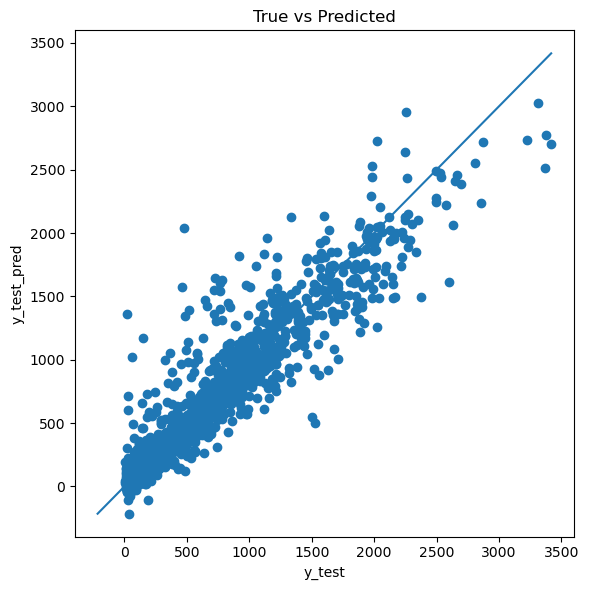

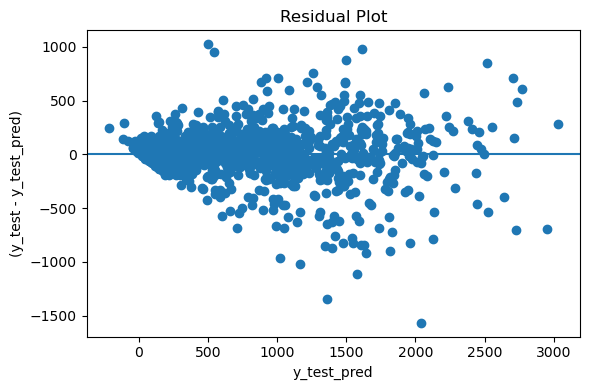

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred)
lims_min = min(np.min(y_test), np.min(y_test_pred))
lims_max = max(np.max(y_test), np.max(y_test_pred))
plt.plot([lims_min, lims_max], [lims_min, lims_max])
plt.xlabel("y_test")
plt.ylabel("y_test_pred")
plt.title("True vs Predicted")
plt.tight_layout()
plt.show()

residuals = y_test - y_test_pred
plt.figure(figsize=(6, 4))
plt.scatter(y_test_pred, residuals)
plt.axhline(0.0)
plt.xlabel("y_test_pred")
plt.ylabel("(y_test - y_test_pred)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()